# Serrodyne Modulation with Electro-Optic Modulators

A light field can be expressed as:

$$E_{in}(t) = E_0 \cos(\omega_c t)$$

the EOM output then becomes:

$$E_{out}(t) = E_0 \cos(\omega_c t + \phi(t))$$

where $\phi(t) = \frac{\pi V(t)}{V_\pi}$ is the phase shift proportional to the applied voltage. The voltage $V_\pi$ is the half-wave voltage required for a $\pi$ phase shift.

First, we import a couple of necessary module and define utility functions for visualization.

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def plot_time_domain(t, signal, title="Time Domain Signal", xlabel="Time [s]", ylabel="Amplitude"):
    plt.figure(figsize=(12, 4))
    plt.plot(t, signal, linewidth=1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_fft(signal, sample_rate, title="Frequency Spectrum", xlim=None):
    N = len(signal)
    fft_values = np.fft.fft(signal)
    freq = np.fft.fftshift(np.fft.fftfreq(N, 1/sample_rate))
    magnitude = np.fft.fftshift(np.abs(fft_values)) / N  # Normalize
    
    plt.figure(figsize=(12, 4))
    plt.plot(freq, magnitude, linewidth=1)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude (normalized)')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    if xlim:
        plt.xlim(xlim)
    plt.tight_layout()
    peak_idx = np.argmax(magnitude)
    print(f"Peak: {freq[peak_idx]:.2f} Hz, Magnitude: {magnitude[peak_idx]:.4f}")
    plt.show()
    return freq, magnitude

If we consider the modulation voltage to be a sawtooth waveform:
$$V_s(t) = 2NV_\pi [(f_m t \bmod 1) - \frac{1}{2}]$$
where $f_m$ is the modulation frequency, the phase shift becomes:
$$\phi(t) = \frac{\pi}{V_\pi} \cdot V_s(t)$$
which means the output field is:
$$E_{out}(t) = E_0 \cos(\omega_c t + 2\pi N [(f_m t \bmod 1) - \frac{1}{2}])$$

To demonstrate this, we first generate a carrier signal. We need to define some basic parameters.

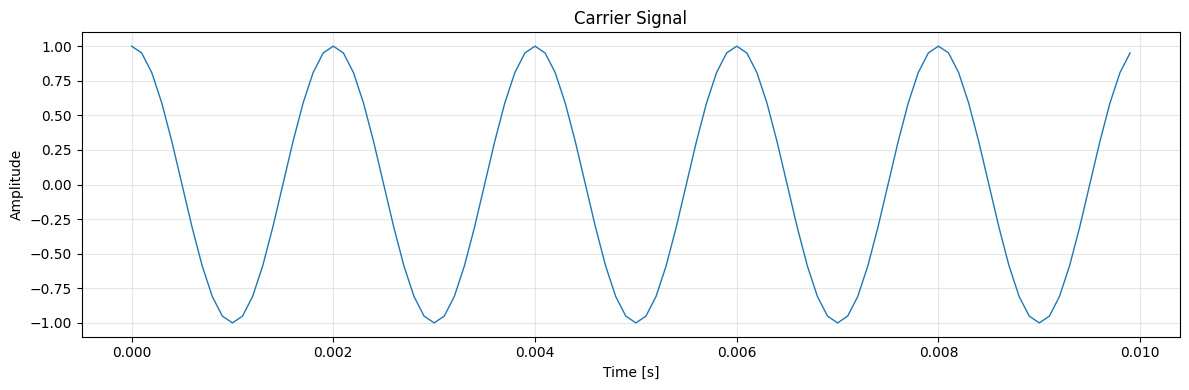

In [53]:
fs = 10000          # Sampling rate [Hz]
duration = 0.5      # Duration [s]
N = int(fs * duration) # Total number of samples
t = np.arange(N) / fs  # Time vector
f_c = 500           # Carrier frequency [Hz]


carrier = np.cos(2*np.pi*f_c*t)

# Plot time domain and frequency domain
plot_time_domain(t[:100], carrier[:100], title="Carrier Signal")

Then we define the modulation signal.

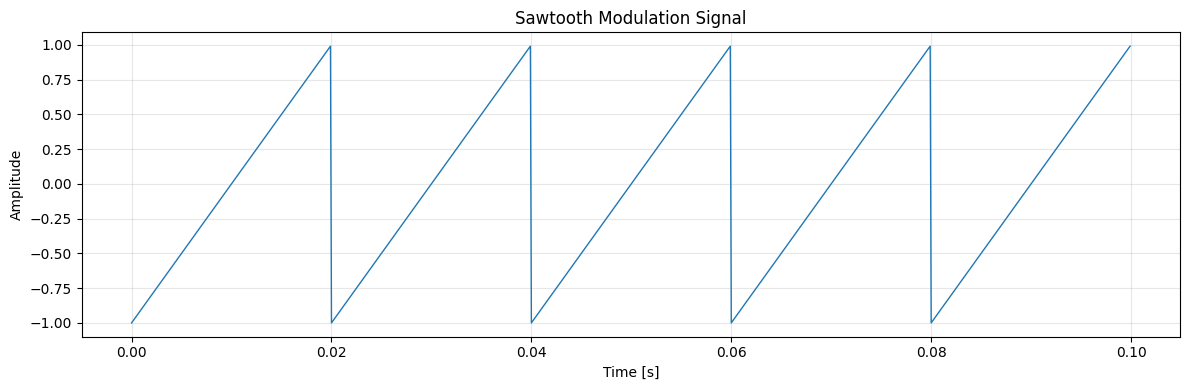

In [54]:
from scipy.signal import sawtooth

f_m = 50            # Modulation frequency
N_order = 1         # Serrodyne order: frequency shift = N_order * f_m
modulator = sawtooth(2*np.pi*f_m*t)  # Sawtooth modulation signal
# Phase shift: φ(t) = π * N_order * sawtooth(2π f_m t)
phase = np.pi * N_order * modulator
plot_time_domain(t[:1000], modulator[:1000], title="Sawtooth Modulation Signal")

Then we apply the modulation to the carrier.

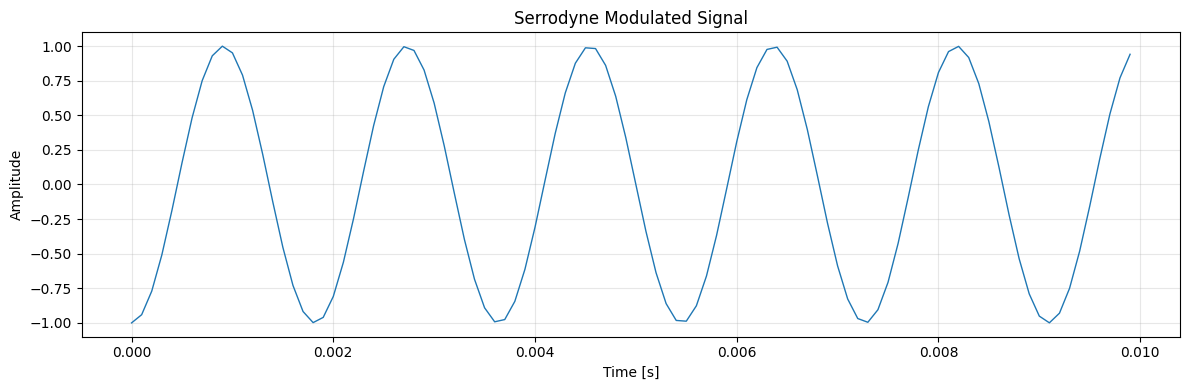

In [55]:
# Apply phase modulation to the carrier: E_out = cos(ω_c t + φ(t))
E_serrodyne = np.cos(2*np.pi*f_c*t + phase)

plot_time_domain(t[:100], E_serrodyne[:100], title="Serrodyne Modulated Signal")

Now we can compare the spectra of the original and modulated signals. The FFT will show that the carrier has been shifted by the modulation frequency $f_m$.

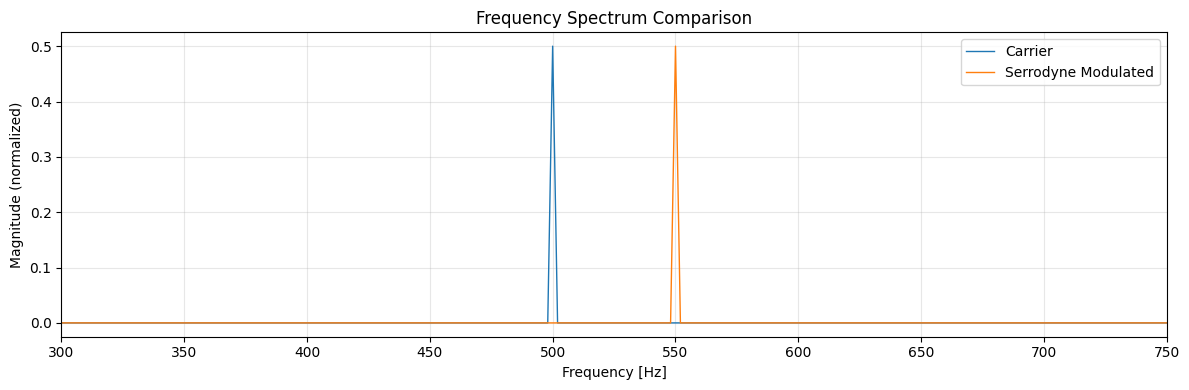

In [56]:
freq = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
fft_carrier = np.fft.fftshift(np.abs(np.fft.fft(carrier))) / N
fft_serrodyne = np.fft.fftshift(np.abs(np.fft.fft(E_serrodyne))) / N


plt.figure(figsize=(12, 4))
plt.plot(freq, fft_carrier, label='Carrier', linewidth=1)
plt.plot(freq, fft_serrodyne, label='Serrodyne Modulated', linewidth=1)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude (normalized)')
plt.title('Frequency Spectrum Comparison')
plt.grid(True, alpha=0.3)
plt.xlim(f_c - 200, f_c + 250)
plt.legend()
plt.tight_layout()
plt.show()

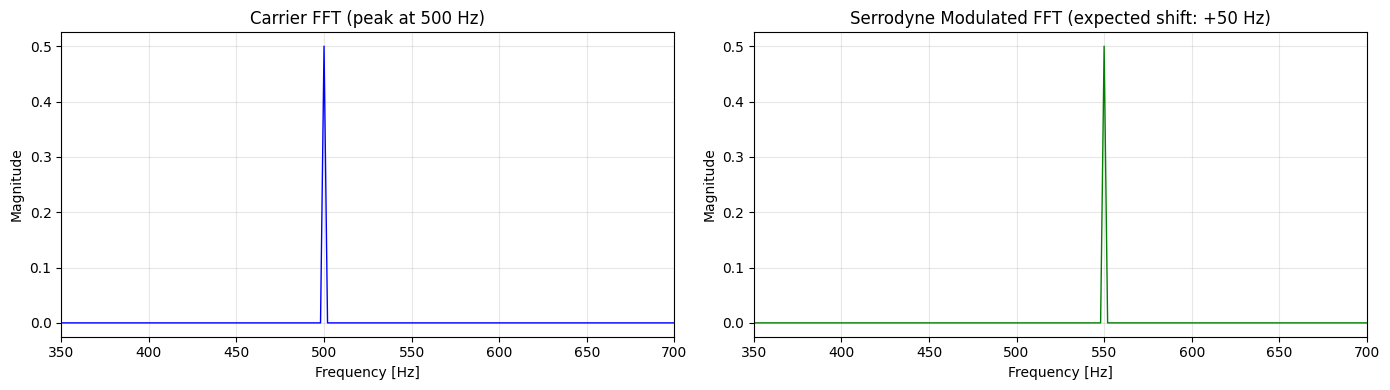

Top carrier frequency peaks (Hz): [-500.  500.  502.]
Top modulated frequency peaks (Hz): [-550. -548.  550.]
Expected frequency shift: 50 Hz


In [57]:
# Compute FFTs
freq = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
fft_carrier = np.fft.fftshift(np.abs(np.fft.fft(carrier))) / N
fft_serrodyne = np.fft.fftshift(np.abs(np.fft.fft(E_serrodyne))) / N

freq_min = f_c - 150
freq_max = f_c + 200

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(freq, fft_carrier, 'b-', linewidth=1)
axes[0].set_title(f'Carrier FFT (peak at {f_c} Hz)')
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_ylabel('Magnitude')
axes[0].set_xlim(freq_min, freq_max)
axes[0].grid(True, alpha=0.3)

axes[1].plot(freq, fft_serrodyne, 'g-', linewidth=1)
axes[1].set_title(f'Serrodyne Modulated FFT (expected shift: +{N_order*f_m} Hz)')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('Magnitude')
axes[1].set_xlim(freq_min, freq_max)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find peaks
carrier_peaks = freq[np.argsort(fft_carrier)[-3:]]
modulated_peaks = freq[np.argsort(fft_serrodyne)[-3:]]
print(f"Top carrier frequency peaks (Hz): {np.sort(carrier_peaks)}")
print(f"Top modulated frequency peaks (Hz): {np.sort(modulated_peaks)}")
print(f"Expected frequency shift: {N_order*f_m} Hz")